In [1]:
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
import seaborn as snn
from mlxtend.plotting import plot_decision_regions
import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout
from tensorflow.keras.optimizers import Adam
print("done")

done


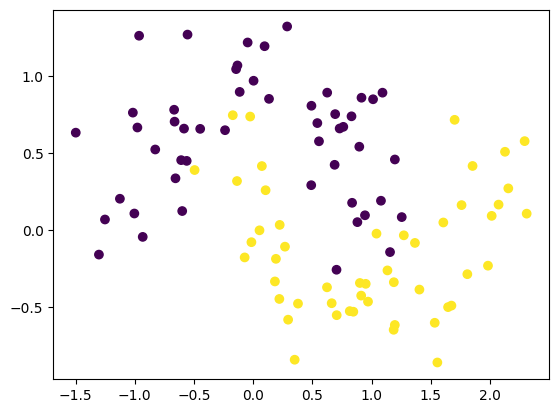

In [2]:
X,y= make_moons(100,noise=0.25,random_state=2)
plt.scatter(X[:,0],X[:,1],c=y)
plt.show()

In [4]:
model1=Sequential()
model1.add(Dense(128,input_dim=2,activation="relu"))
model1.add(Dense(128,activation="relu"))
model1.add(Dense(1,activation="sigmoid"))
model1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
adam=Adam(learning_rate=0.01)
model1.compile(loss='binary_crossentropy',optimizer=adam,metrics=['accuracy'])
history=model1.fit(X,y,epochs=2000,validation_split=0.2,verbose=2)


Epoch 1/2000
3/3 - 1s - 306ms/step - accuracy: 0.9750 - loss: 0.1707 - val_accuracy: 0.9500 - val_loss: 0.2075
Epoch 2/2000
3/3 - 0s - 33ms/step - accuracy: 0.9750 - loss: 0.0404 - val_accuracy: 0.8500 - val_loss: 1.3234
Epoch 3/2000
3/3 - 0s - 32ms/step - accuracy: 0.9750 - loss: 0.1237 - val_accuracy: 0.9000 - val_loss: 0.6953
Epoch 4/2000
3/3 - 0s - 33ms/step - accuracy: 0.9875 - loss: 0.0216 - val_accuracy: 1.0000 - val_loss: 3.1070e-04
Epoch 5/2000
3/3 - 0s - 32ms/step - accuracy: 0.9750 - loss: 0.2586 - val_accuracy: 1.0000 - val_loss: 6.6934e-04
Epoch 6/2000
3/3 - 0s - 33ms/step - accuracy: 0.9625 - loss: 0.1289 - val_accuracy: 0.9500 - val_loss: 0.1008
Epoch 7/2000
3/3 - 0s - 34ms/step - accuracy: 0.9875 - loss: 0.0242 - val_accuracy: 0.8500 - val_loss: 0.7849
Epoch 8/2000
3/3 - 0s - 34ms/step - accuracy: 0.9875 - loss: 0.0191 - val_accuracy: 0.9500 - val_loss: 0.3364
Epoch 9/2000
3/3 - 0s - 32ms/step - accuracy: 1.0000 - loss: 0.0018 - val_accuracy: 0.9500 - val_loss: 0.2030
E

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 8s 824us/step


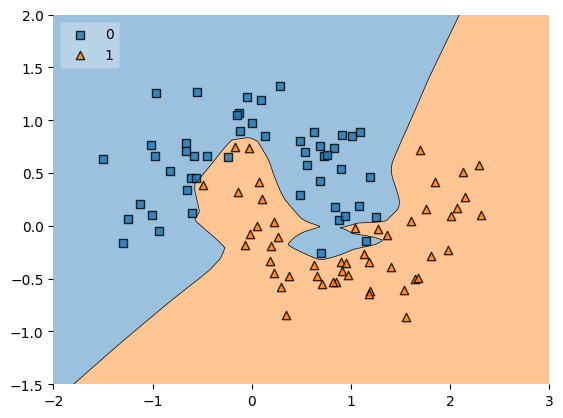

In [8]:
plot_decision_regions(X, y.astype('int'), clf=model1, legend=2)
plt.xlim(-2,3)
plt.ylim(-1.5,2)
plt.show()

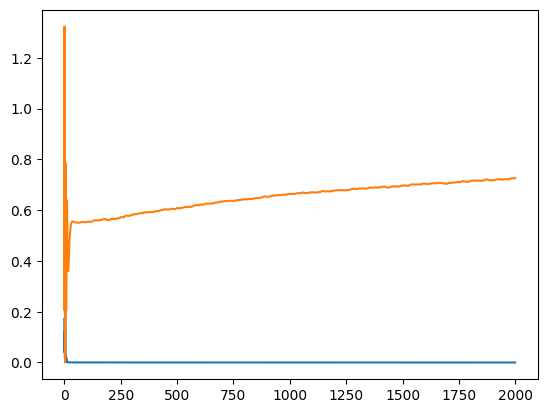

In [9]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

Fix

In [10]:
model2 = Sequential()

model2.add(Dense(128,input_dim=2, activation="relu",kernel_regularizer=tensorflow.keras.regularizers.l1(0.001)))
model2.add(Dense(128, activation="relu",kernel_regularizer=tensorflow.keras.regularizers.l1(0.001)))
model2.add(Dense(1,activation='sigmoid'))

model2.summary()

c:\Users\Yaali Madad\Desktop\programs\Deeplearning\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
adam = Adam(learning_rate=0.01)
model2.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])

history2 = model2.fit(X, y, epochs=2000, validation_split = 0.2,verbose=2)

Epoch 1/2000
3/3 - 1s - 338ms/step - accuracy: 0.9125 - loss: 0.3528 - val_accuracy: 0.8500 - val_loss: 0.4403
Epoch 2/2000
3/3 - 0s - 36ms/step - accuracy: 0.9000 - loss: 0.3978 - val_accuracy: 0.9500 - val_loss: 0.3058
Epoch 3/2000
3/3 - 0s - 34ms/step - accuracy: 0.9500 - loss: 0.2933 - val_accuracy: 1.0000 - val_loss: 0.2385
Epoch 4/2000
3/3 - 0s - 33ms/step - accuracy: 0.9125 - loss: 0.3161 - val_accuracy: 1.0000 - val_loss: 0.2151
Epoch 5/2000
3/3 - 0s - 37ms/step - accuracy: 0.9125 - loss: 0.2803 - val_accuracy: 0.9000 - val_loss: 0.3043
Epoch 6/2000
3/3 - 0s - 35ms/step - accuracy: 0.9375 - loss: 0.3307 - val_accuracy: 0.9000 - val_loss: 0.3193
Epoch 7/2000
3/3 - 0s - 35ms/step - accuracy: 0.9625 - loss: 0.2986 - val_accuracy: 0.9500 - val_loss: 0.2239
Epoch 8/2000
3/3 - 0s - 33ms/step - accuracy: 0.9000 - loss: 0.2741 - val_accuracy: 1.0000 - val_loss: 0.2041
Epoch 9/2000
3/3 - 0s - 34ms/step - accuracy: 0.9000 - loss: 0.2833 - val_accuracy: 1.0000 - val_loss: 0.2111
Epoch 10/

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 7s 708us/step


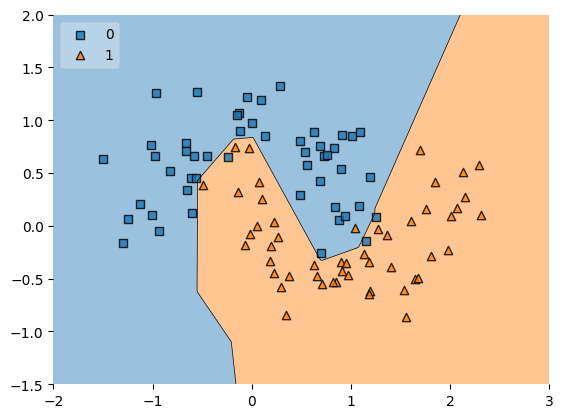

In [13]:
plot_decision_regions(X, y.astype('int'), clf=model2, legend=2)
plt.xlim(-2,3)
plt.ylim(-1.5,2)
plt.show()

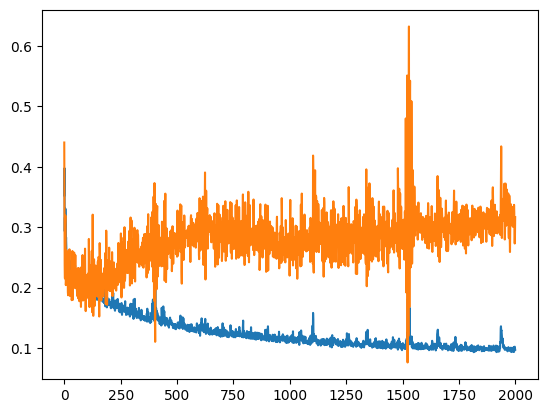

: 

In [ ]:
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])